
State Schema With DataClasses

When we define a LangGraph StateGraph, we use a state schema.

The state schema represents the structure and types of data that our graph will use.

All nodes are expected to communicate with that schema.

LangGraph offers flexibility in how you define your state schema, accommodating various Python types and validation approaches!

user: User = {"name": "Kajal", "age": "twenty"}  # age should be int

👉 IDE will complain:

“Expected int, got str”

✔ This is static checking

In [1]:
from typing_extensions import TypedDict
from typing import Literal


class TypedDictState(TypedDict):
    name:str
    game:Literal["cricket","bedminton"]


👉 Nodes return partial state updates, and LangGraph merges them into the global state.

In [2]:
def play_game(state:TypedDictState):
    print("---play game node has been called---")
    return {"name":state['name']+'want to play '}

def cricket(state:TypedDictState):
    print("---cricket node has been called---")
    return {"game":"cricket"}

def bedminton(state:TypedDictState):
    print("---bedminton node has been called---")
    return {"game":"bedminton"}

In [4]:
import random

def decide_play(state:TypedDictState)->Literal["cricket","bedminton"]:
    if random.random()<0.5:
        return "cricket"
    else:
        return "bedminton"

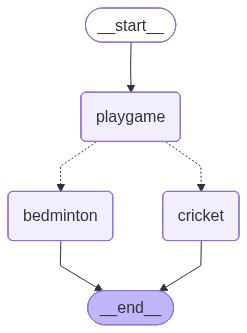

In [7]:
from langgraph.graph  import StateGraph,START,END
from IPython.display import Image , display

builder=StateGraph(TypedDictState)
builder.add_node("playgame",play_game)

builder.add_node("cricket",cricket)
builder.add_node("bedminton",bedminton)

builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("bedminton",END)

graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [8]:
graph.invoke({"name":"kajal"})

---play game node has been called---
---bedminton node has been called---


{'name': 'kajalwant to play ', 'game': 'bedminton'}